# 03 - Entrenamiento y Evaluación
## EduRisk: Early Student Dropout Prediction

Objetivo: Entrenar múltiples modelos de clasificación sobre las features
de matrícula (Grupo A), comparar su rendimiento y seleccionar el mejor
modelo para despliegue.

**Modelos supervisados:**
- LogisticRegression
- RandomForestClassifier
- XGBClassifier
- ExtraTreesClassifier
- GradientBoostingClassifier

**Modelo no supervisado:** KMeans  
**Métrica principal:** F1-weighted

In [1]:
# Utilidades estándar
import warnings
import hashlib
import pickle
import time
from pathlib import Path
warnings.filterwarnings('ignore')

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos supervisados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Modelo no supervisado
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Búsqueda de hiperparámetros
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint

# Métricas y evaluación
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, roc_curve, auc, silhouette_score
)

# Configuración de visualización
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

 # Explicaciones de SHAP
import shap


In [2]:
NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent

processed_path = ROOT / 'data' / 'processed' / 'data_processed.parquet'
df = pd.read_parquet(processed_path)

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Shape: (4424, 29)
Columnas: ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target', 'parents_qualification_avg', 'financial_risk', 'age_group', 'is_first_choice']


In [3]:
df.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target', 'parents_qualification_avg',
       'financial_risk', 'age_group', 'is_first_choice'],
      dtype='str')

## 1. Preparación de datos

In [4]:
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Guardamos los splits en data/train/ y data/test/
TRAIN_DIR = ROOT / 'data' / 'train'
TEST_DIR  = ROOT / 'data' / 'test'
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

df_train= X_train.copy()
df_train['Target'] = y_train

df_test = X_test.copy()
df_test['Target'] = y_test

df_train.to_parquet(TRAIN_DIR / 'train.parquet', index=False)
df_test.to_parquet(TEST_DIR  / 'test.parquet',  index=False)

print(f"Train guardado: {df_train.shape}")
print(f"Test guardado:  {df_test.shape}")
print()
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nDistribución train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribución test:")
print(y_test.value_counts(normalize=True).round(3))

Train guardado: (3539, 29)
Test guardado:  (885, 29)

X_train: (3539, 28)
X_test:  (885, 28)

Distribución train:
Target
2    0.499
0    0.321
1    0.179
Name: proportion, dtype: float64

Distribución test:
Target
2    0.499
0    0.321
1    0.180
Name: proportion, dtype: float64


## 2. Preprocesamiento – ColumnTransformer

Las transformaciones se definen aquí pero se aplican DENTRO de cada
Pipeline durante el entrenamiento.  
Esto evita data leakage, el scaler y el encoder aprenden únicamente de X_train y aplican esos parámetros a X_test.

Las 28 features se dividen en tres grupos según su s datos:

- **Continuas (7)**: Escala grande o variable, StandardScaler lleva
  todo a media=0, desviación=1 para que ninguna variable domine
  por tener números más grandes.

- **Nominales (9)**: Variables categóricas sin orden real codificadas
  como enteros por los autores del dataset. Aplicamos OneHotEncoder
  para que el modelo no asuma que por ejemplo Course=9991 es mayor que Course=33.
  Usamos drop='first' para evitar multicolinealidad perfecta.

- **Binarias y ordinales (12)**: Ya están en escala 0-1 o tienen
  orden real. Se pasan sin transformación.

In [5]:
# Continuas que pasarán por StandardScaler
COLS_SCALE = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
    'parents_qualification_avg'
]

# Nominales sin orden real que pasarán por OneHotEncoder
COLS_OHE = [
    'Marital Status',
    'Application mode',
    'Course',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
]

# Binarias y ordinales se omiten de transformaciones passthrough
COLS_PASSTHROUGH = [
    'Application order',
    'Daytime/evening attendance',
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
    'financial_risk',
    'age_group',
    'is_first_choice'
]

print(f"Columnas a escalar ({len(COLS_SCALE)}): {COLS_SCALE}")
print(f"Columnas OHE ({len(COLS_OHE)}): {COLS_OHE}")
print(f"Columnas passthrough ({len(COLS_PASSTHROUGH)}): {COLS_PASSTHROUGH}")
print(f"Total input: {len(COLS_SCALE) + len(COLS_OHE) + len(COLS_PASSTHROUGH)}")

# Pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), COLS_SCALE),
        ('ohe', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore'
        ), COLS_OHE),
        ('passthrough', 'passthrough', COLS_PASSTHROUGH)
    ]
)

Columnas a escalar (7): ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP', 'parents_qualification_avg']
Columnas OHE (9): ['Marital Status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Columnas passthrough (12): ['Application order', 'Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'financial_risk', 'age_group', 'is_first_choice']
Total input: 28


In [6]:
df['Course'].value_counts()

Course
9500    766
9147    380
9238    355
9085    337
9773    331
9991    268
9670    268
9254    252
9070    226
171     215
8014    215
9003    210
9853    192
9119    170
9130    141
9556     86
33       12
Name: count, dtype: int64

### Decisión: ColumnTransformer selectivo

**¿Qué hace ColumnTransformer?**
Aplica transformaciones diferentes a grupos de columnas diferentes
en un solo objeto que vive dentro del Pipeline.

**¿Por qué StandardScaler solo en continuas?**
Los modelos basados en distancia (SVC, KMeans, etc.) calculan distancias
entre puntos. Sin escalar, `Admission grade` (95-190) dominaría
completamente sobre `Debtor` (0-1) por tener números 100 veces
más grandes. StandardScaler lleva todo a **media=0, desviación=1**.

**¿Qué pasa si escalara las binarias también?**
No rompe el modelo ni cambia los resultados significativamente.
La información se conserva. Pero se evita por tres razones:
- **Interpretabilidad**: Los coeficientes pierden sentido directo
- **Precisión conceptual**: Escalar lo que no necesita escala es señal
  de no entender los datos

**¿Por qué todo va dentro del Pipeline?**
Si escalara antes del split, el scaler ve X_test durante el fit.
Eso es data **leakage**, en producción nunca veré datos futuros
antes de predecir. Dentro del Pipeline, el scaler aprende
únicamente de X_train y aplica esos parámetros a X_test.

## 3. Pipelines por modelo

Cada modelo tiene su propio Pipeline que encadena el preprocesador
con el estimador. Ventajas:

- Sin data leakage: las transformaciones se ajustan solo al train
- Reproducible: en producción se aplican exactamente las mismas
  transformaciones
- GridSearchCV: incluye el preprocesado en la validación cruzada

SVC fue descartado por tiempo de entrenamiento inviable (O(n²)), tarda mucho para esta cantidad de registros.
Se sustituyó por ExtraTreesClassifier que es no lineal, rápido
y complementario a RandomForest.

In [7]:
MODELS = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            # device='mps', # Solo para aceleración en Mac con GPU Apple Silicon
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'ExtraTrees': Pipeline([
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
    ]),
    'GradientBoosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(
            random_state=42
        ))
    ]),
}

print(f"Modelos definidos: {list(MODELS.keys())}")

Modelos definidos: ['LogisticRegression', 'RandomForest', 'XGBoost', 'ExtraTrees', 'GradientBoosting']


## 4. GridSearchCV y RandomizedSearchCV

Se aplican dos estrategias para buscar los mejores hiperparámetros según el modelo:

- **GridSearchCV**: prueba todas las combinaciones posibles de una
  lista fija de valores. Se usa cuando el número de combinaciones
  es pequeño y manejable.

- **RandomizedSearchCV**: prueba N combinaciones elegidas al azar
  de un rango de valores. Se usa cuando los hiperparámetros pueden
  tomar cualquier valor dentro de un rango continuo.

Todos los modelos usan validación cruzada de 5 folds (cv=5), métrica f1_weighted y todos los núcleos disponibles (n_jobs=-1).

Se usa **f1_weighted** como métrica de búsqueda porque pondera el F1
de cada clase por su número de muestras, dando una evaluación
equitativa del modelo sobre las tres clases.  
Si se usara Recall
de Dropout directamente, el modelo optimizaría solo esa clase
ignorando las demás, produciendo predicciones sesgadas.   
El Recall de Dropout se aplica únicamente como **criterio de
selección del modelo final**, una vez todos los modelos
están correctamente entrenados.

In [8]:
PARAM_GRIDS = {
    'LogisticRegression': {
        'type': 'grid',
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__solver': ['lbfgs', 'saga']
        }
    },
    'RandomForest': {
        'type': 'grid',
        'params': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [3, 5, 7],       # quitamos 10 y None
            'model__min_samples_split': [5, 10],  # más restrictivo
            'model__min_samples_leaf': [2, 4]     # nuevo — controla hojas
        }
    },
    'XGBoost': {
        'type': 'random',
        'params': {
            'model__n_estimators': randint(100, 300),
            'model__max_depth': randint(3, 6),
            'model__learning_rate': uniform(0.01, 0.1),
            'model__subsample': uniform(0.5, 0.4),
            'model__colsample_bytree': uniform(0.5, 0.4),
            'model__min_child_weight': randint(5, 15),
            'model__reg_alpha': uniform(0, 1),      # regularización L1
            'model__reg_lambda': uniform(1, 3)      # regularización L2
        }
    },
    'GradientBoosting': {
        'type': 'random',
        'params': {
            'model__n_estimators': randint(150, 350),
            'model__max_depth': randint(3, 5),      # subimos un poco
            'model__learning_rate': uniform(0.05, 0.15),
            'model__subsample': uniform(0.7, 0.25),
            'model__min_samples_leaf': randint(2, 5) # menos restrictivo
        }
    },
    'ExtraTrees': {
        'type': 'grid',
        'params': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [3, 5, 7],       # eliminamos None completamente
            'model__min_samples_split': [5, 10],
            'model__min_samples_leaf': [2, 4]    # nuevo — crítico para ET
        }
    }
}

In [9]:
best_models = {}
results = []

for name, pipeline in MODELS.items():
    print(f"\nEntrenando {name}...")
    start = time.time()

    config = PARAM_GRIDS.get(name)

    if config['type'] == 'grid':
        search = GridSearchCV(
            pipeline,
            config['params'],
            cv=5,
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=0
        )
    else:
        search = RandomizedSearchCV(
            pipeline,
            config['params'],
            n_iter=30,
            cv=5,
            scoring='f1_weighted',
            n_jobs=-1,
            random_state=42,
            verbose=0
        )

    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_

    elapsed = time.time() - start
    print(f"  Mejores params: {search.best_params_}")
    print(f"  F1-weighted CV: {search.best_score_:.4f}")
    print(f"  Tiempo: {elapsed:.1f}s")

print("\nEntrenamiento completado.")


Entrenando LogisticRegression...
  Mejores params: {'model__C': 0.1, 'model__solver': 'saga'}
  F1-weighted CV: 0.6216
  Tiempo: 5.6s

Entrenando RandomForest...
  Mejores params: {'model__max_depth': 7, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 300}
  F1-weighted CV: 0.6184
  Tiempo: 6.2s

Entrenando XGBoost...
  Mejores params: {'model__colsample_bytree': np.float64(0.661803250848876), 'model__learning_rate': np.float64(0.09877700987609599), 'model__max_depth': 5, 'model__min_child_weight': 5, 'model__n_estimators': 299, 'model__reg_alpha': np.float64(0.7853406511139436), 'model__reg_lambda': np.float64(3.006964764142686), 'model__subsample': np.float64(0.7322746485745819)}
  F1-weighted CV: 0.6359
  Tiempo: 6.5s

Entrenando ExtraTrees...
  Mejores params: {'model__max_depth': 7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
  F1-weighted CV: 0.6160
  Tiempo: 5.2s

Entrenando GradientBoosting...
  M

## 5. Evaluación sobre test set

### 5.1 Análisis de overfitting y ranking final

In [10]:
print(" Análisis de overfitting \n")
ranking = []

for name, model in best_models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    y_proba      = model.predict_proba(X_test)

    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    f1_test  = f1_score(y_test,  y_pred_test,  average='weighted')
    diff     = f1_train - f1_test
    status   = "OK" if diff < 0.05 else "MODERADO" if diff < 0.15 else "ALTO"

    report = classification_report(
        y_test, y_pred_test,
        target_names=['Dropout', 'Enrolled', 'Graduate'],
        output_dict=True
    )
    roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    print(f"{name}: Train={f1_train:.4f} | Test={f1_test:.4f} | Diff={diff:.4f} | {status}")

    ranking.append({
        'Modelo':           name,
        'F1 Test':          round(f1_test, 4),
        'Recall Dropout':   round(report['Dropout']['recall'], 4),
        'ROC-AUC':          round(roc, 4),
        'Overfitting':      status
    })

print("\n Ranking final por Recall Dropout \n")
ranking_df = pd.DataFrame(ranking).sort_values('Recall Dropout', ascending=False)
print(ranking_df.to_string(index=False))

 Análisis de overfitting 

LogisticRegression: Train=0.6562 | Test=0.6026 | Diff=0.0536 | MODERADO
RandomForest: Train=0.6657 | Test=0.5973 | Diff=0.0683 | MODERADO
XGBoost: Train=0.8666 | Test=0.6183 | Diff=0.2483 | ALTO
ExtraTrees: Train=0.6581 | Test=0.5886 | Diff=0.0694 | MODERADO
GradientBoosting: Train=0.8676 | Test=0.6012 | Diff=0.2665 | ALTO

 Ranking final por Recall Dropout 

            Modelo  F1 Test  Recall Dropout  ROC-AUC Overfitting
      RandomForest   0.5973          0.6479   0.7558    MODERADO
        ExtraTrees   0.5886          0.6197   0.7507    MODERADO
           XGBoost   0.6183          0.5986   0.7689        ALTO
LogisticRegression   0.6026          0.5915   0.7606    MODERADO
  GradientBoosting   0.6012          0.5915   0.7593        ALTO


### Conclusión del análisis de overfitting

| Modelo | F1 Test | Recall Dropout | ROC-AUC | Overfitting |
|---|---|---|---|---|
| RandomForest | 0.5973 | **0.6479** | 0.7558 | MODERADO |
| ExtraTrees | 0.5886 | 0.6197 | 0.7507 | MODERADO |
| XGBoost | 0.6183 | 0.5986 | 0.7689 | ALTO |
| LogisticRegression | 0.6026 | 0.5915 | 0.7606 | MODERADO |
| GradientBoosting | 0.6012 | 0.5915 | 0.7593 | ALTO |

RandomForest es el candidato principal por tres razones:
- Mayor Recall Dropout (0.6479), detecta más abandonos reales
- Overfitting controlado (diff=0.068) frente a XGBoost (diff=0.248)
- La introducción de OneHotEncoder mejoró LogisticRegression de
  F1=0.53 a F1=0.60, confirmando que el preprocesamiento correcto
  impacta significativamente el rendimiento

### 5.2 Matrices de confusión

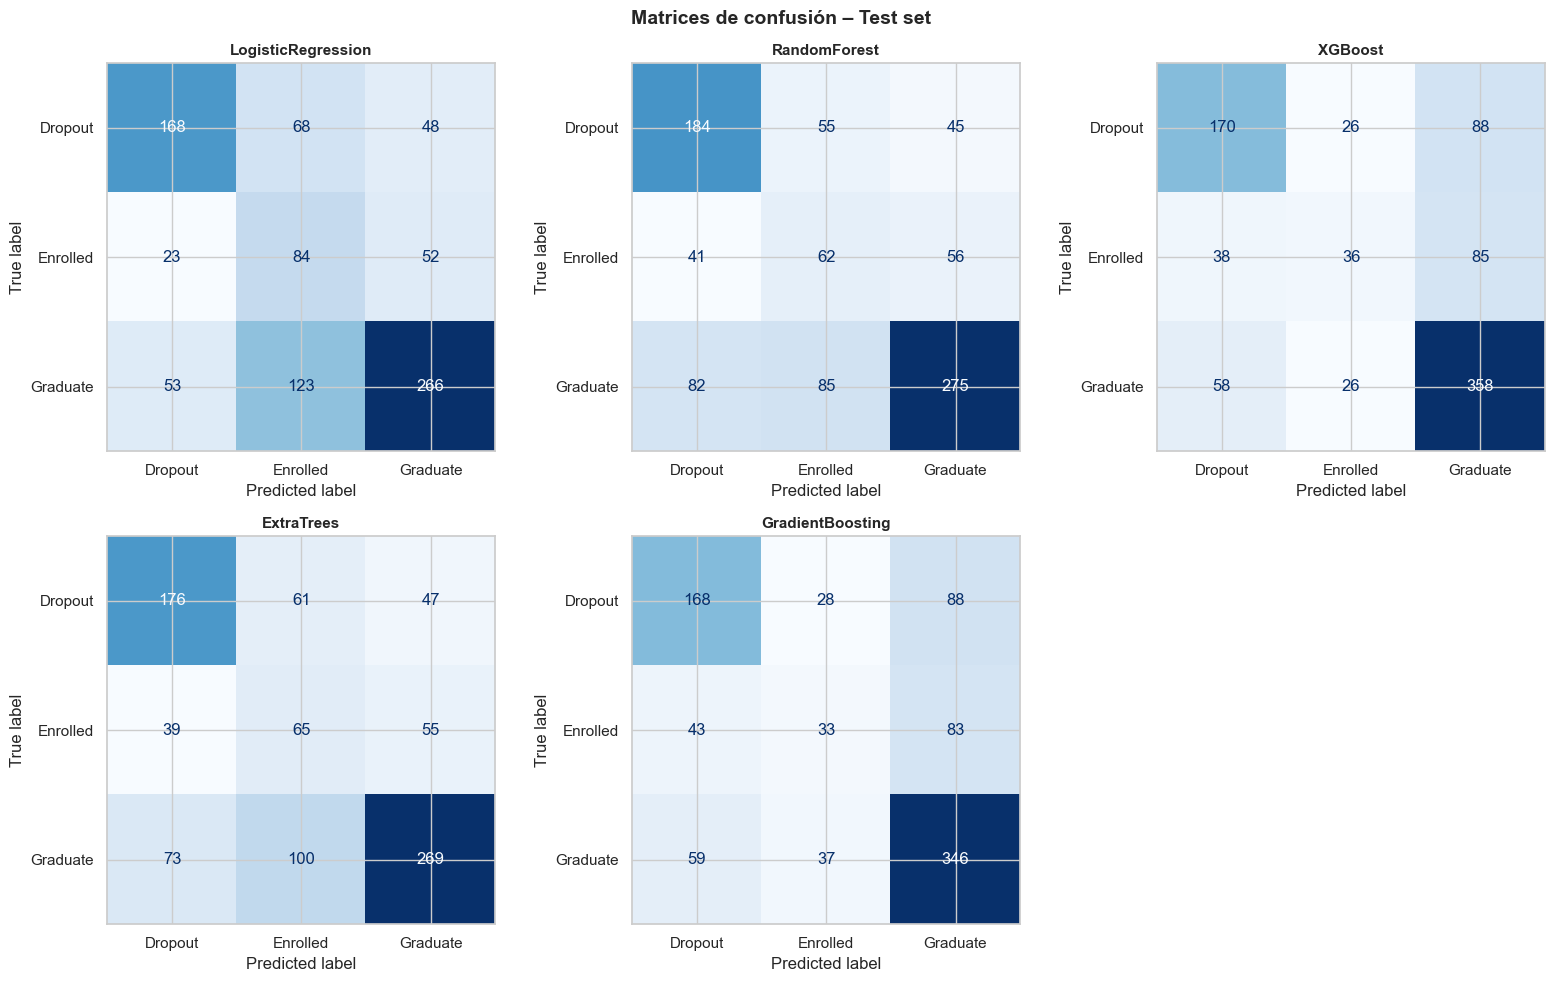

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Dropout', 'Enrolled', 'Graduate']
    )    
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}', fontsize=11, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Matrices de confusión – Test set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones en las matrices de confusión

El análisis se centra en los Falsos Negativos de Dropout (estudiantes
que realmente abandonan pero el modelo predice que no lo harán).

| Modelo | Dropout detectado | Falsos Negativos | Recall Dropout |
|---|---|---|---|
| RandomForest | **184/284** | 100 | **64.8%** |
| ExtraTrees | 176/284 | 108 | 62.0% |
| XGBoost | 170/284 | 114 | 59.9% |
| LogisticRegression | 168/284 | 116 | 59.2% |
| GradientBoosting | 168/284 | 116 | 59.2% |

RandomForest comete menos errores críticos, deja escapar
solo 100 abandonos reales frente a los 116 de GradientBoosting.

**Patrón común en todos los modelos:** la clase Enrolled es la
más difícil de predecir correctamente. Muchos Enrolled se
confunden con Graduate — consistente con la naturaleza ambigua
de esa clase (estudiantes que aún no han terminado).

### 5.3 Classification report

In [12]:
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    f1 = f1_score(y_test, y_pred, average='weighted')
    roc = roc_auc_score(y_test, y_proba,
                        multi_class='ovr', average='macro')

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  F1-weighted: {f1:.4f} | ROC-AUC: {roc:.4f}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Dropout', 'Enrolled', 'Graduate']
    ))


  LogisticRegression
  F1-weighted: 0.6026 | ROC-AUC: 0.7606
              precision    recall  f1-score   support

     Dropout       0.69      0.59      0.64       284
    Enrolled       0.31      0.53      0.39       159
    Graduate       0.73      0.60      0.66       442

    accuracy                           0.59       885
   macro avg       0.57      0.57      0.56       885
weighted avg       0.64      0.59      0.60       885


  RandomForest
  F1-weighted: 0.5973 | ROC-AUC: 0.7558
              precision    recall  f1-score   support

     Dropout       0.60      0.65      0.62       284
    Enrolled       0.31      0.39      0.34       159
    Graduate       0.73      0.62      0.67       442

    accuracy                           0.59       885
   macro avg       0.55      0.55      0.55       885
weighted avg       0.61      0.59      0.60       885


  XGBoost
  F1-weighted: 0.6183 | ROC-AUC: 0.7689
              precision    recall  f1-score   support

     Dropout  

### Observaciones del classification report

**Precision**: De los que predijo como X, cuántos eran realmente X.   
**Recall**: De los que eran realmente X, cuántos detectó correctamente.   
**F1-score**: Balance entre precision y recall por clase.   

| Modelo | Precision Dropout | Recall Dropout | Recall Enrolled | Recall Graduate |
|---|---|---|---|---|
| LogisticRegression | 0.69 | 0.59 | 0.53 | 0.60 |
| RandomForest | 0.60 | **0.65** | 0.39 | 0.62 |
| XGBoost | 0.64 | 0.60 | 0.23 | **0.81** |
| ExtraTrees | 0.61 | 0.62 | 0.41 | 0.61 |
| GradientBoosting | 0.62 | 0.59 | 0.21 | 0.78 |

**Observaciones clave:**

- RandomForest tiene el mejor Recall Dropout (0.65) con un balance
  razonable entre las tres clases. Es el modelo más útil para
  el objetivo de negocio.

- XGBoost sacrifica Enrolled (0.23) y Dropout (0.60) para maximizar
  Graduate (0.81). Útil si el objetivo fuera predecir graduados
  pero no para detección de abandono.

- Enrolled es la clase más difícil para todos los modelos.
  Ninguno supera 0.53 de Recall.

### 5.4 Curvas ROC: Comparativa de modelos

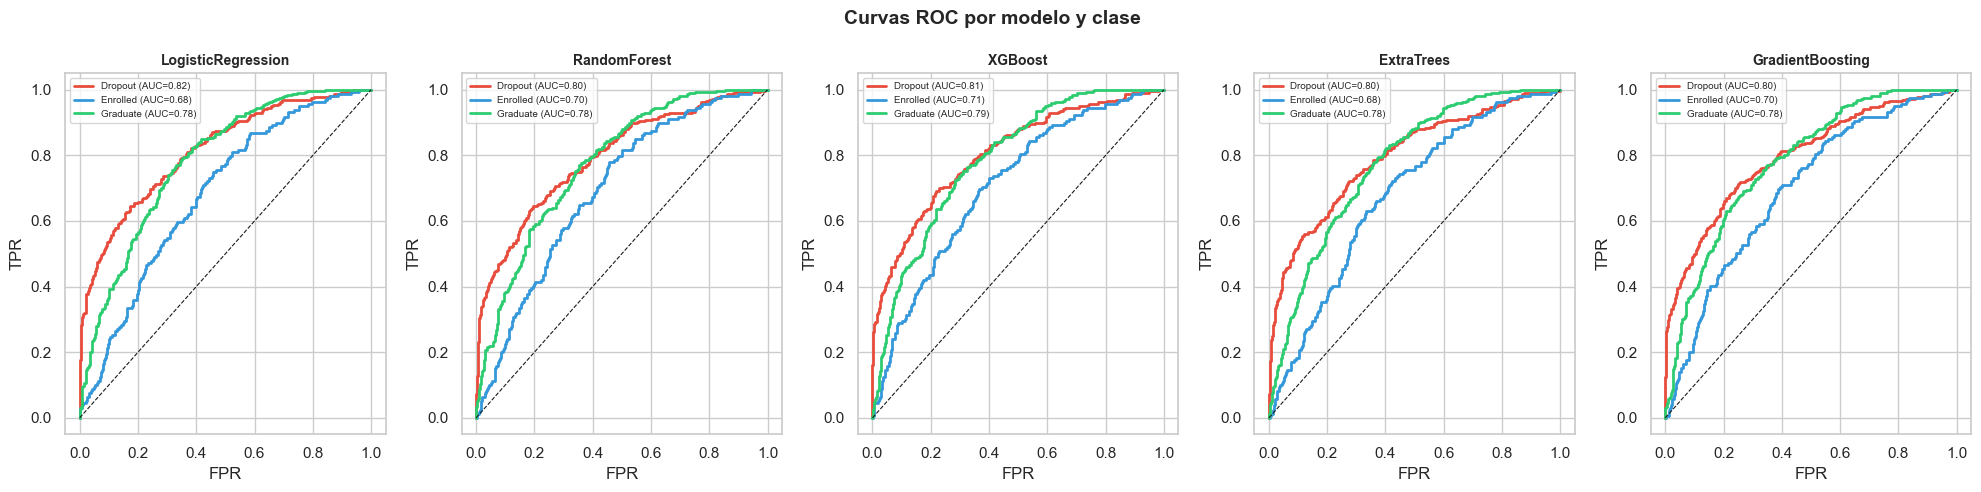

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (name, model) in zip(axes, best_models.items()):
    y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
    y_proba = model.predict_proba(X_test)

    for i, (cls, color) in enumerate(zip(
        ['Dropout', 'Enrolled', 'Graduate'],
        ['#e74c3c', '#3498db', '#2ecc71']
    )):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{cls} (AUC={roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=7)

plt.suptitle('Curvas ROC por modelo y clase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observaciones de las curvas ROC

| Modelo | AUC Dropout | AUC Enrolled | AUC Graduate |
|---|---|---|---|
| LogisticRegression | **0.82** | 0.68 | 0.78 |
| RandomForest | 0.80 | 0.70 | 0.78 |
| XGBoost | 0.81 | **0.71** | **0.79** |
| ExtraTrees | 0.80 | 0.68 | 0.78 |
| GradientBoosting | 0.80 | 0.70 | 0.78 |

LogisticRegression tiene el AUC más alto en Dropout (0.82) gracias
al OneHotEncoder que mejoró significativamente su capacidad
discriminante. Sin embargo su Recall real es inferior a RandomForest
porque AUC mide capacidad de separación general, no el punto
de operación óptimo para la clase minoritaria.

XGBoost lidera en Enrolled y Graduate pero con overfitting alto
(diff=0.248) lo que compromete su fiabilidad en producción.

RandomForest mantiene AUC competitivo (0.80 Dropout) con
overfitting controlado, confirma su selección como modelo final.

## 6. Guardado de modelos

Se serializan todos los modelos entrenados en formato `.pkl` usando
`pickle`. Se genera un checksum SHA256 del modelo final para
verificar su integridad en futuros usos.

In [14]:
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Guardar todos los modelos
for name, model in best_models.items():
    model_path = MODELS_DIR / f'trained_model_{name.lower()}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Guardado: {model_path.name}")

# Guardar modelo final
final_model_path = MODELS_DIR / 'final_model.pkl'
with open(final_model_path, 'wb') as f:
    pickle.dump(best_models['RandomForest'], f)

# Checksum
h = hashlib.sha256()
with open(final_model_path, 'rb') as f:
    for chunk in iter(lambda: f.read(8192), b''):
        h.update(chunk)
checksum = h.hexdigest()
(MODELS_DIR / 'final_model.pkl.sha256').write_text(checksum)

print(f"\nModelo final: final_model.pkl (RandomForest)")
print(f"SHA256: {checksum}")

Guardado: trained_model_logisticregression.pkl
Guardado: trained_model_randomforest.pkl
Guardado: trained_model_xgboost.pkl
Guardado: trained_model_extratrees.pkl
Guardado: trained_model_gradientboosting.pkl

Modelo final: final_model.pkl (RandomForest)
SHA256: 4f6abb987c1d3b23741ed4a8117cb44a61ae9f3cb6706ebd4769ca16b6fe0443


## 7. Interpretación de variables con Feature Importance

Mide cuánto contribuye cada variable a las decisiones del modelo.   
En RandomForest se calcula como la reducción media de impureza
que aporta cada feature en todos los árboles del bosque.

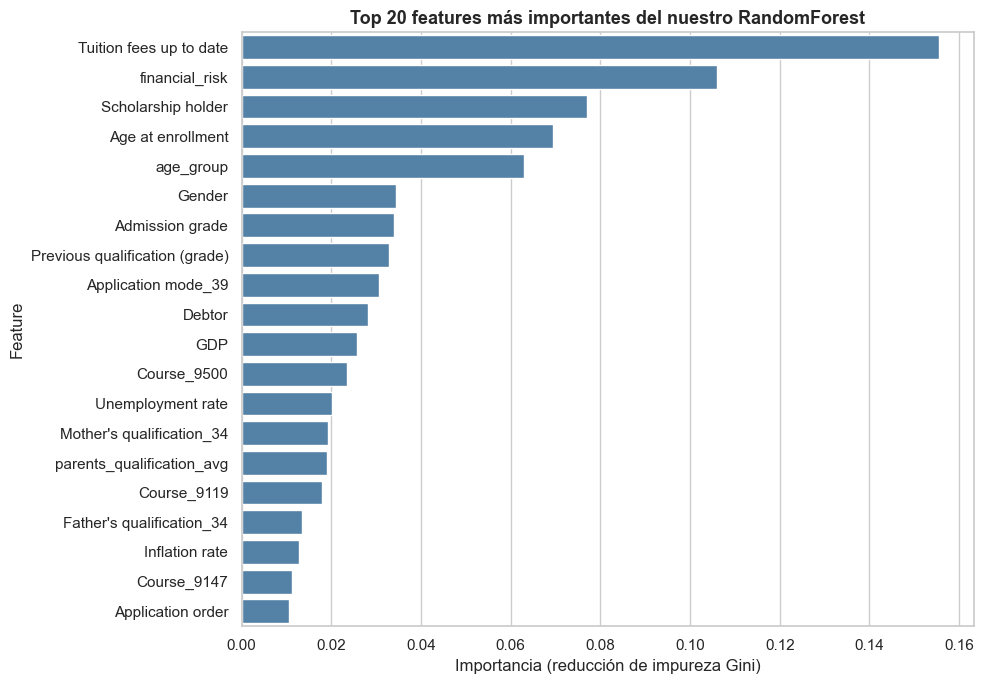


Top 10:
                       Feature  Importance
       Tuition fees up to date    0.155544
                financial_risk    0.106044
            Scholarship holder    0.077093
             Age at enrollment    0.069469
                     age_group    0.063020
                        Gender    0.034482
               Admission grade    0.034047
Previous qualification (grade)    0.032950
           Application mode_39    0.030720
                        Debtor    0.028216


In [15]:
ohe_features = best_models['RandomForest'] \
    .named_steps['preprocessor'] \
    .named_transformers_['ohe'] \
    .get_feature_names_out(COLS_OHE).tolist()

all_features = COLS_SCALE + ohe_features + COLS_PASSTHROUGH

importances = best_models['RandomForest'] \
    .named_steps['model'] \
    .feature_importances_

fi_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(data=fi_df, x='Importance', y='Feature', color='steelblue')
plt.title('Top 20 features más importantes del nuestro RandomForest',
          fontsize=13, fontweight='bold')
plt.xlabel('Importancia (reducción de impureza Gini)')
plt.tight_layout()
plt.show()

print("\nTop 10:")
print(fi_df.head(10).to_string(index=False))

### Observaciones – Feature Importance

Las features más importantes son las que mejor ayudan al modelo
a distinguir entre Dropout, Enrolled y Graduate.

*Los porcentajes provienen del análisis bivariante del notebook 02.
La columna Importancia proviene del modelo RandomForest entrenado.*

| Ranking | Feature | Importancia | Qué dice el dato real |
|---|---|---|---|
| 1 | `Tuition fees up to date` | 0.156 | El 86.6% de los que no están al día con el pago abandonan vs el 24.7% de los que sí lo están. La diferencia más grande de todo el dataset. |
| 2 | `financial_risk` | 0.106 | Feature engineered que combina deuda y pago. Su alta importancia valida la decisión de crearla en el notebook 02. |
| 3 | `Scholarship holder` | 0.077 | El 12.2% de los becados abandona vs el 38.7% de los no becados. Tener beca está fuertemente asociado con terminar la carrera. |
| 4 | `Age at enrollment` | 0.069 | Los estudiantes Dropout tienen mediana de edad ~24 años vs ~19-20 de Enrolled y Graduate. Los estudiantes mayores tienen mayor riesgo. |
| 5 | `age_group` | 0.063 | Versión categorizada de la edad. Ambas variables aparecen porque capturan el mismo fenómeno de forma complementaria. |
| 6 | `Gender` | 0.034 | El 45.1% de los hombres abandona vs el 25.1% de las mujeres en este dataset. |
| 7 | `Admission grade` | 0.034 | Variable continua con separación moderada entre clases según el EDA. |
| 8 | `Previous qualification (grade)` | 0.033 | Rendimiento académico previo aporta información sobre el perfil del estudiante. |
| 9 | `Application mode_39` | 0.031 | Una vía de acceso específica que el modelo identifica como señal de riesgo. |
| 10 | `Debtor` | 0.028 | El 62% de los deudores abandona vs el 28.3% de los no deudores. |

**Importante:** Feature Importance mide qué variables son más
útiles para que el modelo distinga entre clases. No implica
causalidad, no podemos afirmar que no pagar la matrícula
"cause" el abandono, sino que es el indicador más predictivo
disponible en el momento de la matrícula.

**Validación cruzada con el EDA:**
Los resultados son completamente consistentes con el análisis
bivariante del notebook 02. Las mismas variables identificadas
visualmente como más discriminantes son las más importantes
para el modelo, lo que confirma que el análisis exploratorio
fue correcto y riguroso.

**El perfil de riesgo que emerge:**
Un estudiante con alto riesgo de abandono en este dataset
tiende a ser: mayor de 25 años, hombre, sin beca, con
dificultades de pago y accediendo por una vía no convencional.

**Mi sesgo (suposición)**: Este perfil es coherente con la literatura académica sobre
abandono universitario en Portugal y "España".

## 8. Modelo no supervisado: KMeans

KMeans agrupa estudiantes en clusters según su perfil de matrícula
sin usar el target. El objetivo no es predecir sino descubrir
patrones naturales en los datos que aporten valor adicional
al análisis, es decir, una segmentación de perfiles de riesgo.

In [16]:
# Usamos todas las features menos el target
X_cluster = df.drop(columns=['Target'])

scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X_cluster)

pca_kmeans = PCA(n_components=3, random_state=42)
X_pca = pca_kmeans.fit_transform(X_scaled)

print(f"Varianza explicada por componente: {pca_kmeans.explained_variance_ratio_.round(3)}")
print(f"Varianza total explicada: {pca_kmeans.explained_variance_ratio_.sum():.3f}")

Varianza explicada por componente: [0.155 0.096 0.082]
Varianza total explicada: 0.332


### 8.1 PCA para clustering

Los 3 componentes explican el 33.2% de la varianza total.
Es bajo pero esperado — el dataset tiene muchas variables
categóricas ordinales poco correlacionadas entre sí.

Se usan 3 componentes por dos razones:
- Permite visualización en 2D
- KMeans funciona mejor en espacios de baja dimensionalidad
  donde las distancias son más significativas

Limitación: los clusters representan patrones en el espacio
reducido, no en el espacio original completo.

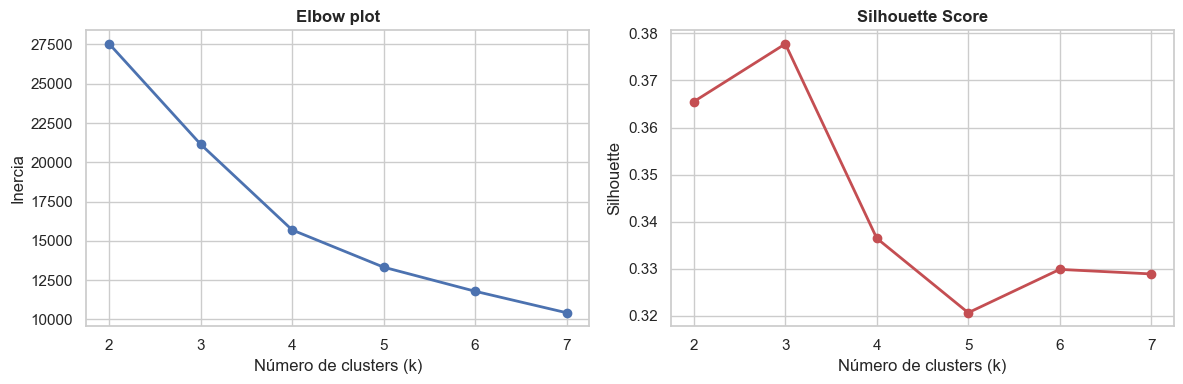

Silhouette scores:
  k=2: 0.3655
  k=3: 0.3778
  k=4: 0.3365
  k=5: 0.3207
  k=6: 0.3299
  k=7: 0.3289


In [17]:
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow plot', fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

### 8.2 Selección de k

| k | Silhouette | Observación |
|---|---|---|
| 2 | 0.3655 | Aceptable pero agrupa demasiado |
| **3** | **0.3778** | **Máximo debido a que muestra mejor separación** |
| 4 | 0.3365 | Cae significativamente |
| 5 | 0.3207 | Mínimo |
| 6 | 0.3299 | Ligera recuperación |
| 7 | 0.3289 | Sin mejora |

**Elbow plot:** No muestra un codo pronunciado,la inercia
baja de forma gradual sin un punto de inflexión claro.

**Silhouette Score:** Sí muestra un máximo claro en k=3
(0.3778) con caída pronunciada en k=4 (0.3365). Es el
criterio determinante para la elección.

**Decisión: k=3** basada principalmente en Silhouette Score.

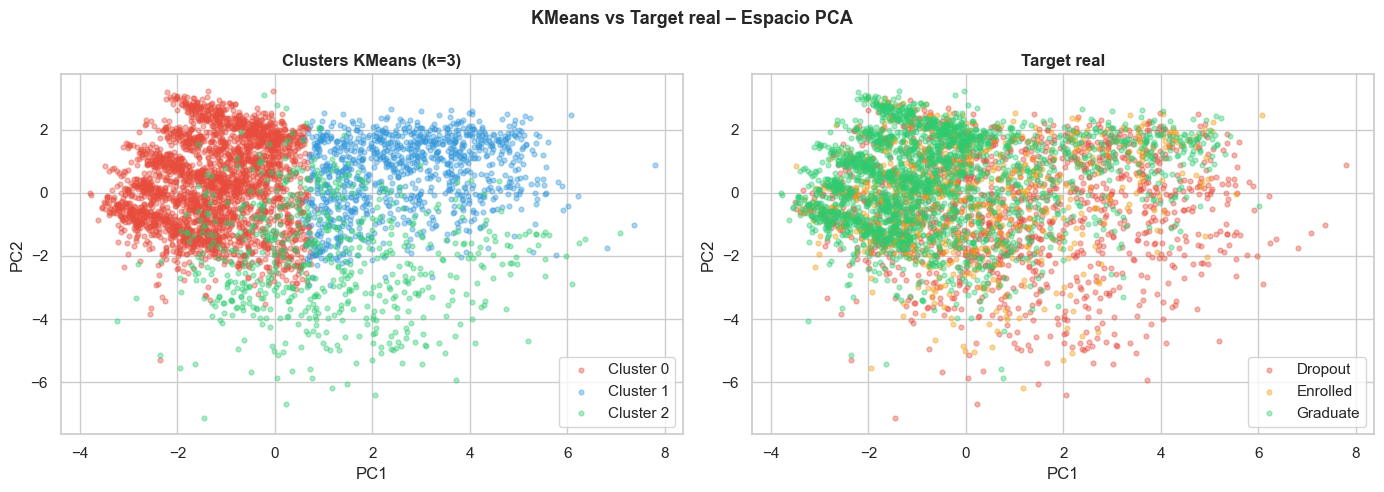

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

df_cluster = df.copy()
df_cluster['cluster'] = clusters

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_colors = ['#e74c3c', '#3498db', '#2ecc71']
target_colors  = ['#e74c3c', '#f39c12', '#2ecc71']

for k in range(3):
    mask = clusters == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=cluster_colors[k],
                   label=f'Cluster {k}',
                   alpha=0.4, s=12)
axes[0].set_title('Clusters KMeans (k=3)', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

for t, label in enumerate(['Dropout', 'Enrolled', 'Graduate']):
    mask = df['Target'].values == t
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=target_colors[t],
                   label=label,
                   alpha=0.4, s=12)
axes[1].set_title('Target real', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('KMeans vs Target real – Espacio PCA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Análisis visual del KMeans vs Target real

**Clusters KMeans:** Tres grupos espacialmente diferenciados
en el espacio PCA. Cluster 0 se concentra a la izquierda,
Cluster 1 al centro-derecha, Cluster 2 distribuido.

**Target real:** Los Dropout aparecen distribuidos por todo
el espacio sin una zona de concentración nítida. Los Graduate
dominan el centro y la derecha. Los Enrolled son pocos y
aparecen mezclados.

**Conclusión:** Los clusters no se corresponden directamente
con el target. El valor del clustering no es
predecir sino descubrir perfiles de estudiante que luego
se analizan en detalle con el perfil de clusters.

In [19]:
profile_cols = [
    'Age at enrollment', 'Tuition fees up to date',
    'Scholarship holder', 'Debtor', 'financial_risk',
    'Admission grade', 'Gender'
]

print("Perfil de los clusters\n")
for k in range(3):
    mask = clusters == k
    print(f"Cluster {k} — {mask.sum()} estudiantes")
    print(df_cluster[mask][profile_cols].mean().round(2))
    print("Target predominante:")
    print(df_cluster[mask]['Target'].value_counts(normalize=True).round(2))
    print()

Perfil de los clusters

Cluster 0 — 2770 estudiantes
Age at enrollment           19.59
Tuition fees up to date      0.99
Scholarship holder           0.32
Debtor                       0.01
financial_risk               0.02
Admission grade            127.28
Gender                       0.29
dtype: float64
Target predominante:
Target
2    0.62
0    0.20
1    0.19
Name: proportion, dtype: float64

Cluster 1 — 1003 estudiantes
Age at enrollment           33.08
Tuition fees up to date      0.90
Scholarship holder           0.14
Debtor                       0.06
financial_risk               0.15
Admission grade            127.36
Gender                       0.44
dtype: float64
Target predominante:
Target
0    0.45
2    0.39
1    0.16
Name: proportion, dtype: float64

Cluster 2 — 651 estudiantes
Age at enrollment           23.80
Tuition fees up to date      0.38
Scholarship holder           0.12
Debtor                       0.65
financial_risk               1.27
Admission grade            125

### 8.4 Perfil de clusters

| Característica | Cluster 0 | Cluster 1 | Cluster 2 |
|---|---|---|---|
| Estudiantes | 2.770 (62.6%) | 1.003 (22.7%) | 651 (14.7%) |
| Edad media | 19.6 años | 33.1 años | 23.8 años |
| Matrícula al día | 99% | 90% | 38% |
| Beca | 32% | 14% | 12% |
| Deudor | 1% | 6% | 65% |
| Riesgo financiero | 0.02 | 0.15 | 1.27 |
| Nota admisión | 127.3 | 127.4 | 125.1 |
| % Dropout | 20% | 45% | **64%** |
| % Graduate | 62% | 39% | 18% |

**Cluster 0: Perfil bajo riesgo (20% abandona)**
Estudiantes jóvenes (~20 años), sin deudas, matrícula al día,
el 32% tiene beca. Perfil tradicional con apoyo financiero.
El 62% se gradúa.

**Cluster 1: Perfil riesgo moderado (45% abandona)**
Estudiantes maduros (~33 años), probable trabajador en activo.
Sin beca, matrícula relativamente al día. El riesgo viene de
la edad y la "presión laboral", no del factor financiero.

**Cluster 2: Perfil alto riesgo (64% abandona)**
Grave riesgo financiero, 65% son deudores, solo el 38% tiene
la matrícula al día, financial_risk=1.27. Sin beca.
Es el cluster prioritario para intervención urgente.

**Valor de negocio:** KMeans descubre tres perfiles accionables.
Una universidad puede diseñar intervenciones diferenciadas:
apoyo financiero urgente para Cluster 2, flexibilidad horaria
y tutoría para Cluster 1, seguimiento estándar para Cluster 0.

In [20]:
kmeans_pipeline = {
    'scaler': scaler_kmeans,
    'pca': pca_kmeans,
    'kmeans': kmeans
}

kmeans_path = MODELS_DIR / 'trained_model_kmeans.pkl'
with open(kmeans_path, 'wb') as f:
    pickle.dump(kmeans_pipeline, f)

h = hashlib.sha256()
with open(kmeans_path, 'rb') as f:
    for chunk in iter(lambda: f.read(8192), b''):
        h.update(chunk)
checksum = h.hexdigest()
(MODELS_DIR / 'trained_model_kmeans.pkl.sha256').write_text(checksum)

print(f"Guardado: {kmeans_path.name}")
print(f"SHA256: {checksum}")

Guardado: trained_model_kmeans.pkl
SHA256: 1f5b9571ef0c2370d99fd1a5fbb58522e469cb5953006a05b2062c1432b92301


## 9. Conclusión del notebook 03

### Modelos entrenados y evaluados

| Modelo | Búsqueda | F1-CV | F1 Test | ROC-AUC | Recall Dropout | Overfitting |
|---|---|---|---|---|---|---|
| RandomForest | GridSearch | 0.6184 | 0.5973 | 0.7558 | **0.6479** | MODERADO |
| XGBoost | RandomizedSearch | 0.6359 | 0.6183 | 0.7689 | 0.5986 | ALTO |
| LogisticRegression | GridSearch | 0.6216 | 0.6026 | 0.7606 | 0.5915 | MODERADO |
| GradientBoosting | RandomizedSearch | 0.6434 | 0.6012 | 0.7593 | 0.5915 | ALTO |
| ExtraTrees | GridSearch | 0.6160 | 0.5886 | 0.7507 | 0.6197 | MODERADO |
| KMeans | No supervisado | Silhouette=0.378 | 3 clusters | k=3 | — | — |

### Modelo final seleccionado: RandomForest

Justificación: Mayor Recall Dropout (0.6479) con overfitting
moderado y controlado (diff=0.068). El objetivo de negocio es
no dejar escapar estudiantes en riesgo de abandono, por eso Recall
Dropout es la métrica principal.

### Decisión de preprocesamiento

OneHotEncoder sobre variables nominales mejoró LogisticRegression
de F1=0.53 a F1=0.60 (+0.07), confirmando que el tratamiento
correcto de categóricas impacta el rendimiento especialmente
en modelos lineales.

### Limitaciones y próximos pasos

- Dataset pequeño (4.424 registros) limita la generalización
- XGBoost y GradientBoosting con overfitting alto (diff>0.20)
  a pesar de la regularización aplicada
- Próximos pasos: SHAP values para explicabilidad individual,
  ccp_alpha para poda, Optuna para optimización bayesiana

### Archivos generados en models/
- trained_model_logisticregression.pkl
- trained_model_randomforest.pkl
- trained_model_xgboost.pkl
- trained_model_extratrees.pkl
- trained_model_gradientboosting.pkl
- trained_model_kmeans.pkl
- final_model.pkl (RandomForest)
- final_model.pkl.sha256

### Explicatibilidad con SHAP.

El clúster que nos interesa es de color azul, podemos ver que la primera variable y la tercera variable son las más importantes para predecir.

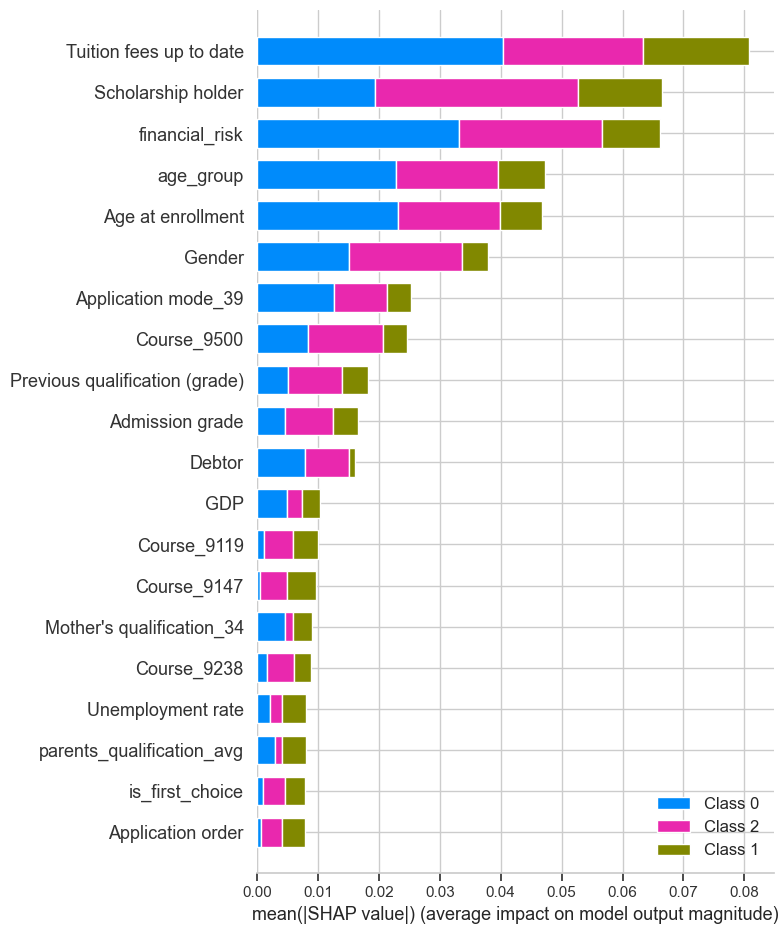

In [21]:
explainer = shap.Explainer(best_models['RandomForest'].named_steps['model'])
X_test_transformed = best_models['RandomForest'].named_steps['preprocessor'].transform(X_test)
shap_values = explainer(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed, feature_names=all_features)
